In [2]:
# import statements --> SOME OF THESE MAY NOT BE NEEDED
%matplotlib inline 
import numpy as np 

from matplotlib import pyplot as plt 
from matplotlib.cm import get_cmap
#from matplotlib.ticker import MaxNLocator
#import matplotlib.gridspec as gridspec
#import matplotlib.colors as mcolors
#import colorcet as cc
#from matplotlib.patches import Rectangle, FancyArrowPatch
#import matplotlib.ticker as ticker
#from mpl_toolkits.mplot3d import Axes3D
#from mpl_toolkits.axes_grid1 import make_axes_locatable
#import mpl_scatter_density
#from astropy.visualization import LogStretch
#from astropy.visualization.mpl_normalize import ImageNormalize

#import h5py

#from astropy.io import fits,ascii,votable
#from astropy import units as u 
#from astropy import constants as const
#from astropy import table
#from astropy.cosmology import Planck15,FlatLambdaCDM
#from astropy.table import Table

#from sklearn.cluster import KMeans
#from sklearn import mixture
#from itertools import combinations
#from sklearn.neighbors import KNeighborsRegressor
#from sklearn.utils import check_array
#from sklearn.neighbors._base import _get_weights
#imports for TWO-NN
#import scipy
from sklearn import neighbors
#from sklearn import preprocessing

#import scipy.integrate
#from scipy.integrate import quad
#import numba
#from sklearn.datasets import load_digits
import umap
import umap.plot
from umap.umap_ import nearest_neighbors
import pandas as pd
#import plotly
import plotly.express as px

#imports for plotly graphing
#import plotly.graph_objects as go
#from plotly.subplots import make_subplots

import pickle

pd.set_option('display.max_columns', None)

#BRETT NOTEBOOK IMPORTS
from pathlib import Path

from importlib import reload
import utils
reload(utils)
from minisom import MiniSom

# imports from animation_simplified2 notebook
import seaborn as sns
sns.set(style='white', rc={'figure.figsize':(14, 12), 'animation.html': 'html5'})
import os
import copy

python(75589) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(75810) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(75815) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(75819) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(75822) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(75825) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/Applications/anaconda3/envs/env1/lib/python3.11/site-packages/umap/plot.py:203: NumbaDeprecationWarning: The keyword argument 'nopython=False' was supplied. From Numba 0.59.0 the default is being changed to True and use of 'nopython=False' will raise a warning as the argument will have no effect. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behavi

In [3]:
import umapz2

In [4]:
spec95 = pd.read_parquet('spec95_ugrizyJH_maps_250819.parquet')

In [5]:
spec95

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,nearest_cat1_ID,nearest_cat1_sep,Id_specz,Id_original,ra_original,dec_original,ra_corrected,dec_corrected,Priority,specz,flag,Confidence_level,survey,compilation_year,public_or_private,Id_COS20_Classic,ra_COS20_Classic,dec_COS20_Classic,Id_COS20_Farmer,ra_COS20_Farmer,dec_COS20_Farmer,Id_COSMOS15,ra_COSMOS15,dec_COSMOS15,Id_COSMOS09,ra_COSMOS09,dec_COSMOS09,photoz,photoz_type,UMAP3D-1,UMAP3D-2,UMAP3D-3,SOM-1,SOM-2
0,535,150.726526,1.795723,0,3.135322,0.004911,0.001979,3.543392,0.005600,0.001707,4.149280,0.006839,0.001707,5.531073,0.006686,0.001311,9.094858,0.011055,0.001310,6.137582,0.023292,0.003891,8.654985,0.055195,0.006917,8.847195,0.061729,0.007971,10.089081,0.037653,0.004077,12.819075,0.017958,0.001854,8.697933,0.024042,0.003679,0.8165,0,NaN,28,1.85,8,1.609000e+08,0.2,1,-20.28363,-21.12927,-21.52369,9.31240,9.27122,9.34644,9.33645,1.23468,-8.087,22.659295,22.526452,22.355068,22.042977,21.503010,21.930007,21.556834,21.532986,21.390371,21.130358,21.551460,0.132843,0.171384,0.312092,0.539966,-0.426997,0.373173,0.023848,57552,0.032255,57552,b'3962782953',150.72652,1.79573,150.72652,1.79573,1,0.82589,4,97,29,2023,1,393505,150.726503,1.795736,535,150.726526,1.795723,334248,150.726575,1.795797,495080,150.72654,1.795808,0.7747,0,-1.975816,1.218150,0.035435,11,32
1,670,149.730259,1.959835,0,1.941518,0.005379,0.003476,1.863746,0.004178,0.002408,2.359093,0.005581,0.002440,3.347864,0.005832,0.001883,4.712861,0.009339,0.002130,5.044670,0.019908,0.004038,5.936375,0.013675,0.002495,7.337306,0.017588,0.002736,9.483263,0.026426,0.003042,13.707825,0.014322,0.001382,12.806878,0.012845,0.001335,1.1792,0,NaN,30,1.02,10,2.273000e+08,0.3,0,-20.49749,-21.89549,-22.47231,9.79095,9.75692,9.83047,9.80739,1.80017,-7.953,23.179647,23.224033,22.968137,22.588081,22.216789,22.142918,21.966197,21.736158,21.457606,21.057579,21.131392,-0.044386,0.255896,0.380057,0.371292,0.073870,0.176721,0.230038,54582,0.166286,54582,b'3962783555',149.73022,1.95986,149.73022,1.95986,1,1.16549,4,97,29,2023,1,562463,149.730243,1.959851,670,149.730259,1.959835,437916,149.730268,1.959866,816008,149.73022,1.959921,1.1465,0,-0.919792,-0.326218,5.726158,30,13
2,692,149.642181,2.379960,0,1.315313,0.006756,0.006467,4.484449,0.005892,0.001415,13.213070,0.007819,0.000612,24.048380,0.008534,0.000384,35.020987,0.013526,0.000416,40.134805,0.026583,0.000678,66.579523,0.061359,0.000999,98.679499,0.078428,0.000908,133.665136,0.058089,0.000475,81.719072,0.032358,0.000524,83.615927,0.028347,0.000451,0.3269,0,NaN,29,0.29,9,5.000000e+09,0.4,1,-16.72223,-20.57175,-21.94677,10.35539,10.31772,10.39305,10.38281,0.19029,-10.190,23.602427,22.270727,21.097491,20.447285,20.039179,19.891197,19.341648,18.914433,18.584955,19.119191,19.094277,1.331700,1.173237,0.650205,0.408106,0.147982,0.549549,0.427216,134345,0.069986,134345,b'174323',149.64220,2.37996,149.64217,2.37995,1,0.30572,4,97,105,2018,1,1020227,149.642181,2.379958,692,149.642181,2.379960,715344,149.642185,2.379964,1306281,149.64216,2.379982,0.3098,0,6.842029,6.652438,3.014578,36,35
3,1143,150.589033,1.889879,0,0.063290,0.003653,0.072636,0.254108,0.004009,0.016990,1.155916,0.005216,0.004662,4.069362,0.005549,0.001476,6.65053

In [ ]:
# PROCESSING / SPLITS
soms = pd.read_parquet('som_embeddings_manhattan_260506.parquet')
spec = pd.merge(soms.copy()[soms['ID'].isin(spec95['ID'])], spec95[['ID', 'specz']], left_on='ID', right_on='ID', how='left')
splits = umapz2.data_split(photcat=soms, speccat=spec, valid_size=len(spec), rs=41)
valid = copy.deepcopy(splits['valid'])

In [7]:
valid

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,SOM_8_16_s0.5_lr0.8-1,SOM_8_16_s0.5_lr0.8-2,SOM_8_16_s1_lr0.8-1,SOM_8_16_s1_lr0.8-2,SOM_8_16_s2_lr0.8-1,SOM_8_16_s2_lr0.8-2,SOM_8_16_s4_lr0.8-1,SOM_8_16_s4_lr0.8-2,SOM_12_24_s0.5_lr0.8-1,SOM_12_24_s0.5_lr0.8-2,SOM_12_24_s1_lr0.8-1,SOM_12_24_s1_lr0.8-2,SOM_12_24_s2_lr0.8-1,SOM_12_24_s2_lr0.8-2,SOM_12_24_s4_lr0.8-1,SOM_12_24_s4_lr0.8-2,SOM_18_36_s0.5_lr0.8-1,SOM_18_36_s0.5_lr0.8-2,SOM_18_36_s1_lr0.8-1,SOM_18_36_s1_lr0.8-2,SOM_18_36_s2_lr0.8-1,SOM_18_36_s2_lr0.8-2,SOM_18_36_s4_lr0.8-1,SOM_18_36_s4_lr0.8-2,SOM_25_50_s0.5_lr0.8-1,SOM_25_50_s0.5_lr0.8-2,SOM_25_50_s1_lr0.8-1,SOM_25_50_s1_lr0.8-2,SOM_25_50_s2_lr0.8-1,SOM_25_50_s2_lr0.8-2,SOM_25_50_s4_lr0.8-1,SOM_25_50_s4_lr0.8-2,SOM_35_70_s0.5_lr0.8-1,SOM_35_70_s0.5_lr0.8-2,SOM_35_70_s1_lr0.8-1,SOM_35_70_s1_lr0.8-2,SOM_35_70_s2_lr0.8-1,SOM_35_70_s2_lr0.8-2,SOM_35_70_s4_lr0.8-1,SOM_35_70_s4_lr0.8-2,SOM_50_100_s0.5_lr0.8-1,SOM_50_100_s0.5_lr0.8-2,SOM_50_100_s1_lr0.8-1,SOM_50_100_s1_lr0.8-2,SOM_50_100_s2_lr0.8-1,SOM_50_100_s2_lr0.8-2,SOM_50_100_s4_lr0.8-1,SOM_50_100_s4_lr0.8-2,SOM_75_150_s0.5_lr0.8-1,SOM_75_150_s0.5_lr0.8-2,SOM_75_150_s1_lr0.8-1,SOM_75_150_s1_lr0.8-2,SOM_75_150_s2_lr0.8-1,SOM_75_150_s2_lr0.8-2,SOM_75_150_s4_lr0.8-1,SOM_75_150_s4_lr0.8-2
682744,888967,149.936450,2.785401,0,0.482169,0.008109,0.021217,0.556797,0.004353,0.008433,0.649724,0.005866,0.009340,0.815287,0.006075,0.008074,1.022175,0.009601,0.010115,1.516981,0.023160,0.015645,2.479349,0.054714,0.023929,3.181551,0.075771,0.027204,3.775385,0.057224,0.016556,5.577980,0.014766,0.003503,6.055261,0.017200,0.003780,1.5429,0,NaN,27,0.99,5,1.139000e+09,0.2,0,-19.84784,-21.53190,-22.12276,10.02579,9.89337,10.08403,10.03590,1.14004,-8.917,24.692001,24.535758,24.368177,24.121724,23.876187,23.447549,22.914156,22.643403,22.457597,22.033808,21.944668,0.156243,0.167580,0.246453,0.245537,0.428638,0.533394,0.270753,3,11,1,3,6,2,7,0,9,7,7,7,8,3,9,5,16,13,15,2,13,25,0,32,12,32,10,46,7,36,0,42,27,30,30,16,31,12,7,56,28,94,42,35,29,1,14,25,15,143,41,142,69,112,9,14
705718,915989,150.389923,1.791782,0,0.300923,0.003346,0.013912,0.391560,0.003238,0.008863,0.729946,0.004244,0.005987,0.857738,0.004264,0.005368,0.908493,0.006994,0.008269,1.053736,0.015095,0.014646,1.133205,0.028540,0.027268,1.063807,0.038095,0.040864,1.151679,0.027239,0.025818,0.553292,0.012940,0.030942,0.312715,0.016622,0.070726,0.4445,0,NaN,30,0.00,1,3.210000e+08,0.0,0,-16.35030,-17.63879,-17.70557,8.08427,8.02849,8.19774,8.06536,-1.17000,-9.212,25.203863,24.918003,24.241773,24.066614,24.004195,23.843171,23.764228,23.832843,23.746671,24.542615,25.162128,0.285860,0.676230,0.175160,0.062418,0.161025,0.078942,-0.068615,3,13,6,9,1,7,2,7,6,17,1,13,2,11,1,10,1,10,2,24,4,17,14,20,19,11,4,32,19,22,19,26,33,63,4,63,10,64,23,37,44,14,6,40,39,37,43,53,74,115,33,53,8,120,73,91
132564,175014,150.121155,1.644934,0,0.281661,0.003567,0.015858,0.294709,0.003148,0.011457,0.385362,0.004180,0.011174,0.606247,0.004185,0.007456,0.866615,0.006661,0.008258,0.800703,0.015264,0.019495,0.987316,0.013438,0.014739,0.996477,0.017941,0.020548,0.986751,0.026845,0.029699,0.839995,0.013123,0.020670,0.550881,0.013868,0.033498,0.8564,0,NaN,29,0.00,7,1.015000e+09,0.1,1,-17.75778,-18.94959,-1

In [16]:
# PROCESSING / SPLITS
#soms_35_70 = pd.read_parquet('som_embeddings2M_260327_3570.parquet')
#spec_35_70 = pd.merge(soms_35_70.copy()[soms_35_70['ID'].isin(spec95['ID'])], spec95[['ID', 'specz']], left_on='ID', right_on='ID', how='left')
#soms_50_100 = pd.read_parquet('som_embeddings2M_260316_50100.parquet')
#spec_50_100 = pd.merge(soms_50_100.copy()[soms_50_100['ID'].isin(spec95['ID'])], spec95[['ID', 'specz']], left_on='ID', right_on='ID', how='left')
#splits_35_70 = umapz2.data_split(photcat=soms_35_70, speccat=spec_35_70, valid_size=len(spec_35_70), rs=41)
#valid_35_70 = copy.deepcopy(splits_35_70['valid'])
#splits_50_100 = umapz2.data_split(photcat=soms_50_100, speccat=spec_50_100, valid_size=len(spec_50_100), rs=41)
#valid_50_100 = copy.deepcopy(splits_50_100['valid'])

### SOM quantitative performance (cross-validation test) on all 50x100 grids

In [9]:
reload(umapz2)

<module 'umapz2' from '/Users/finianashmead/Desktop/NEWMANGROUP/umapz2.py'>

In [18]:
if 0:
    sigs = [0.5, 1, 2, 4]
    lrs = [0.2, 0.4, 0.8, 1.0]

    params = [(s, lr) for s in sigs for lr in lrs]

    for s, lr in params:
        map = 'SOM_35_70_s'+str(s)+'_lr'+str(lr)
        umapz2.plot_som_valid(full_df=soms_35_70, valid_df=valid_35_70, map=map, size=(35,70))#, filename=map+'n2M_35_70.png')

In [55]:
valid_highz = valid.copy()[valid['lp_photoz']>1.7]
valid_highz

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,SOM_8_16_s0.25_lr0.8-1,SOM_8_16_s0.25_lr0.8-2,SOM_8_16_s0.5_lr0.8-1,SOM_8_16_s0.5_lr0.8-2,SOM_8_16_s1_lr0.8-1,SOM_8_16_s1_lr0.8-2,SOM_8_16_s2_lr0.8-1,SOM_8_16_s2_lr0.8-2,SOM_12_24_s0.25_lr0.8-1,SOM_12_24_s0.25_lr0.8-2,SOM_12_24_s0.5_lr0.8-1,SOM_12_24_s0.5_lr0.8-2,SOM_12_24_s1_lr0.8-1,SOM_12_24_s1_lr0.8-2,SOM_12_24_s2_lr0.8-1,SOM_12_24_s2_lr0.8-2,SOM_18_36_s0.25_lr0.8-1,SOM_18_36_s0.25_lr0.8-2,SOM_18_36_s0.5_lr0.8-1,SOM_18_36_s0.5_lr0.8-2,SOM_18_36_s1_lr0.8-1,SOM_18_36_s1_lr0.8-2,SOM_18_36_s2_lr0.8-1,SOM_18_36_s2_lr0.8-2,SOM_25_50_s0.25_lr0.8-1,SOM_25_50_s0.25_lr0.8-2,SOM_25_50_s0.5_lr0.8-1,SOM_25_50_s0.5_lr0.8-2,SOM_25_50_s1_lr0.8-1,SOM_25_50_s1_lr0.8-2,SOM_25_50_s2_lr0.8-1,SOM_25_50_s2_lr0.8-2,SOM_35_70_s0.25_lr0.8-1,SOM_35_70_s0.25_lr0.8-2,SOM_35_70_s0.5_lr0.8-1,SOM_35_70_s0.5_lr0.8-2,SOM_35_70_s1_lr0.8-1,SOM_35_70_s1_lr0.8-2,SOM_35_70_s2_lr0.8-1,SOM_35_70_s2_lr0.8-2,SOM_50_100_s0.25_lr0.8-1,SOM_50_100_s0.25_lr0.8-2,SOM_50_100_s0.5_lr0.8-1,SOM_50_100_s0.5_lr0.8-2,SOM_50_100_s1_lr0.8-1,SOM_50_100_s1_lr0.8-2,SOM_50_100_s2_lr0.8-1,SOM_50_100_s2_lr0.8-2,SOM_75_150_s0.25_lr0.8-1,SOM_75_150_s0.25_lr0.8-2,SOM_75_150_s0.5_lr0.8-1,SOM_75_150_s0.5_lr0.8-2,SOM_75_150_s1_lr0.8-1,SOM_75_150_s1_lr0.8-2,SOM_75_150_s2_lr0.8-1,SOM_75_150_s2_lr0.8-2
723834,937354,149.597883,1.958308,0,1.147422,0.007932,0.008682,1.256400,0.005491,0.004699,1.334432,0.006968,0.005389,1.409706,0.007909,0.006068,1.495404,0.012589,0.009053,1.534133,0.026084,0.017402,2.787040,0.055194,0.021457,2.577627,0.073529,0.032567,2.772327,0.052506,0.020680,3.774985,0.019845,0.006956,4.004927,0.024275,0.008066,1.9521,0,NaN,27,2.21,6,360200000.0,0.1,0,-21.13423,-21.92889,-22.22716,9.80746,9.75386,9.86396,9.78709,1.39944,-8.424,23.750692,23.652180,23.586759,23.527179,23.463103,23.435343,22.787142,22.871950,22.792889,22.457712,22.393513,0.098512,0.065421,0.059580,0.064076,0.027761,0.648201,-0.084808,6,12,2,14,5,15,2,1,7,23,0,2,9,8,6,23,14,27,4,30,5,4,13,23,7,20,10,33,17,32,12,7,13,20,24,54,19,31,33,8,29,56,6,25,9,72,20,30,43,132,37,146,1,23,16,145
233927,307349,149.737783,2.566874,0,1.338779,0.003422,0.003190,1.260992,0.003543,0.003006,1.323767,0.004397,0.003416,1.411705,0.004475,0.003419,1.467669,0.006955,0.005086,1.518515,0.015130,0.010181,1.860780,0.010457,0.006082,1.641369,0.013986,0.009721,1.754651,0.019681,0.012242,1.796000,0.010099,0.007439,1.777063,0.014214,0.010642,1.7693,0,NaN,28,2.05,5,127800000.0,0.1,1,-20.92349,-21.36816,-21.21541,9.26111,9.21970,9.29680,9.24698,1.22623,-8.001,23.583227,23.648219,23.595471,23.525640,23.483430,23.446452,23.225763,23.361984,23.289523,23.264234,23.275743,-0.064992,0.052748,0.069831,0.042211,0.036978,0.220689,-0.136222,6,12,2,14,1,15,2,2,2,17,3,5,10,8,5,22,13,14,0,29,6,4,11,24,15,4,9,40,20,36,13,9,31,61,27,64,27,20,34,2,4,22,5,94,6,32,24,27,15,52,7,36,1,28,12,149
516578,687842,150.176315,2.179071,0,0.261435,0.006275,0.029822,0.383888,0.003851,0.010695,0.432995,0.005226,0.012380,0.586061,0.005316,0.009766,0.755326,0.008216,0.011658,0.834277,0.017874,0.021864,2.060208,0.012653,0.006641,2.477593,0.016871,0.007764,3.052657,0.024339,0.008699,4.471376,0.009766,0.002889,5.088316,0.011279,0.002949,1.7803,0,NaN,28,1.69,7,508800

In [13]:
reload(umapz2)

<module 'umapz2' from '/Users/finianashmead/Desktop/NEWMANGROUP/umapz2.py'>

In [17]:
data=valid #_highz

#sizes=[(46,92), (50,100), (54,108)]
#sizes=[(75,)]

#sigmas = [0.85, 1, 1.15]
#learning_rates = [0.68, 0.8, 0.92]

#sizes=[(50,100)]
#sizes=[(75,)]

sigmas = [0.5, 1, 2, 4]
learning_rates = [0.8]

#sizes=[(8,16), (12,24), (18,36), (25,50), (35,70), (50,100), (75,150)]
sizes=[(18,36)]


for size in sizes:
    n_som_xy = size

    if 1:
        sigs = sigmas #[0.5, 1, 2, 4]
        lrs = learning_rates #[0.2, 0.4, 0.8, 1.0]

        params = [(s, lr) for s in sigs for lr in lrs]

        sets = {(s, lr): [0] for (s, lr) in params}
        results = {(s, lr): [0] for (s, lr) in params}

        outliers_mean = []
        outliers_std = []
        nmads_mean = []
        nmads_std = []
        biases_mean = []
        biases_std = []

        for s, lr in params:
            #map = 'SOM_35_70_s'+str(s)+'_lr'+str(lr)
            map = 'SOM_'+str(n_som_xy[0])+'_'+str(n_som_xy[1])+'_s'+str(s)+'_lr'+str(lr)
            #results[(s, lr)], sets[(s, lr)] = umapz2.crossvalidate_global(folds=5, data=data, 
            #                                                            nn=n_som_xy[0], map=map, tv='lp_photoz',
            #                                                            dim=2)
            results[(s, lr)], sets[(s, lr)] = umapz2.crossvalidate_global(folds=5, data=data, 
                                                                        nn=n_som_xy[0], map=map, tv='lp_photoz',
                                                                        dim=2, rematch=True)
    #with open("results_260506_manhattan_"+str(n_som_xy[0])+'_'+str(n_som_xy[1])+".pkl", "wb") as f:
    #    pickle.dump(results, f)

In [20]:
#with open("results_260329_35_70.pkl", "wb") as f:
#    pickle.dump(results, f)

In [11]:
with open("results_260409_46_92.pkl", "rb") as f:
    data_4692 = pickle.load(f)

with open("results_260409_50_100.pkl", "rb") as f:
    data_50100 = pickle.load(f)

with open("results_260409_54_108.pkl", "rb") as f:
    data_54108 = pickle.load(f)

In [8]:
with open("results_260506_manhattan_8_16.pkl", "rb") as f:
    data_816 = pickle.load(f)

with open("results_260506_manhattan_12_24.pkl", "rb") as f:
    data_1224 = pickle.load(f)

with open("results_260506_manhattan_18_36.pkl", "rb") as f:
    data_1836 = pickle.load(f)

with open("results_260506_manhattan_25_50.pkl", "rb") as f:
    data_2550 = pickle.load(f)

with open("results_260506_manhattan_35_70.pkl", "rb") as f:
    data_3570 = pickle.load(f)

with open("results_260506_manhattan_50_100.pkl", "rb") as f:
    data_50100 = pickle.load(f)

with open("results_260506_manhattan_75_150.pkl", "rb") as f:
    data_75150 = pickle.load(f)

data_75150[(1, 0.8)]

{'counts_mean': 2895.4,
 'nn': 75,
 'outliers_mean': 0.03025494040973673,
 'outliers_range': 0.0016214581328555101,
 'nmads_mean': 0.025426366606507676,
 'nmads_range': 0.0003712718594174704,
 'biases_mean': 0.005278492855257592,
 'biases_range': 0.0018534435524480376}

In [24]:
data_50100.keys()

dict_keys([(0.25, 0.8), (0.5, 0.8), (1, 0.8), (2, 0.8)])

In [9]:
data=valid #_highz

#sizes=[(46,92), (50,100), (54,108)]
#sizes=[(75,)]

#sigmas = [0.85, 1, 1.15]
#learning_rates = [0.68, 0.8, 0.92]

#sizes=[(50,100)]
#sizes=[(75,)]

sigmas = [0.5, 1, 2, 4]
learning_rates = [0.8]

#sizes=[(8,16), (12,24), (18,36), (25,50), (35,70), (50,100), (75,150)]
sizes=[(75,150)]


for size in sizes:
    n_som_xy = size

    if 1:
        sigs = sigmas #[0.5, 1, 2, 4]
        lrs = learning_rates #[0.2, 0.4, 0.8, 1.0]

        params = [(s, lr) for s in sigs for lr in lrs]

        mean_sets = {(s, lr): [0] for (s, lr) in params}
        mean_results = {(s, lr): [0] for (s, lr) in params}

        mean_outliers_mean = []
        mean_outliers_std = []
        mean_nmads_mean = []
        mean_nmads_std = []
        mean_biases_mean = []
        mean_biases_std = []

        for s, lr in params:
            #map = 'SOM_35_70_s'+str(s)+'_lr'+str(lr)
            map = 'SOM_'+str(n_som_xy[0])+'_'+str(n_som_xy[1])+'_s'+str(s)+'_lr'+str(lr)
            #results[(s, lr)], sets[(s, lr)] = umapz2.crossvalidate_global(folds=5, data=data, 
            #                                                            nn=n_som_xy[0], map=map, tv='lp_photoz',
            #                                                            dim=2)
            mean_results[(s, lr)], mean_sets[(s, lr)] = umapz2.crossvalidate_global(folds=5, data=data, 
                                                                        nn=n_som_xy[0], map=map, tv='lp_photoz',
                                                                        dim=2, calc='mean',
                                                                        rematch=True)
    #with open("results_260506_manhattan_"+str(n_som_xy[0])+'_'+str(n_som_xy[1])+".pkl", "wb") as f:
    #    pickle.dump(results, f)

In [10]:
dmetrics_data = {'mean':mean_results, 'median':data_75150}
dmetrics = ['mean', 'median']

outliers
nmads
biases


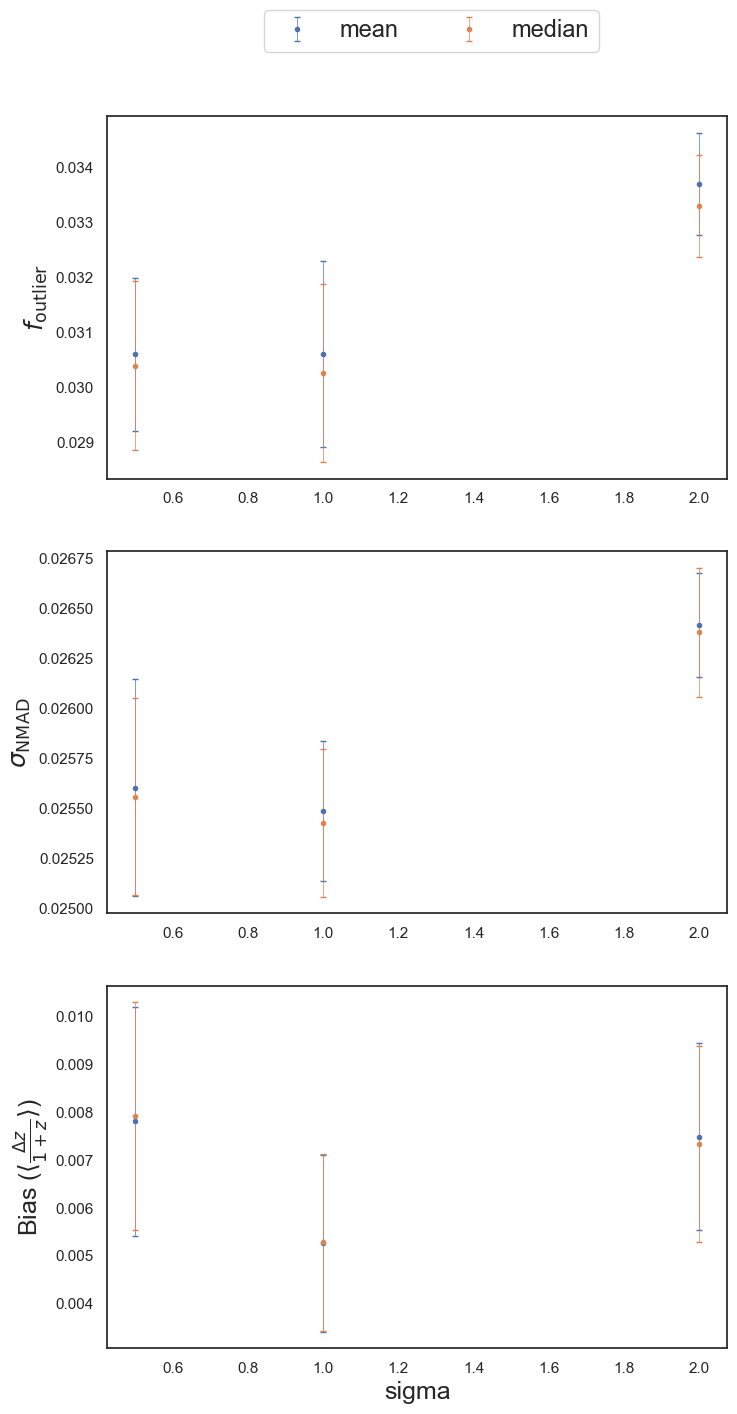

In [20]:
sizes=[(75,150)]
sigmas = [0.5, 1, 2]
learning_rates = [0.8]

filename=None
metrics = ['outliers', 'nmads', 'biases']
labels = r'$f_\mathrm{outlier}$', r'$\sigma_\mathrm{NMAD}$', 'Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')'
fig, axs = plt.subplots(len(metrics), 1, figsize=(8,14))
v1s, v1sl = sizes, 'size'
v2s, v2sl = sigmas, 'sigma'
#cs = 'r', 'g', 'b', '0.5'

for i, metric in enumerate(metrics):
    print(metric)
    for j, dmetric in enumerate(dmetrics):
        vals, errs = [], []
        for k, v2 in enumerate(v2s):
            vals.append(dmetrics_data[dmetric][(sigmas[k], 0.8)][metric+'_mean'])
            errs.append(dmetrics_data[dmetric][(sigmas[k], 0.8)][metric+'_range'])
        #print(str(size)+' SOM min. mean:', np.round(np.min(vals), 5), '  (for sigma='+str(v2s[np.argmin(vals)])+')')

        if i==0:
            axs[i].errorbar(v2s, vals, yerr=errs, fmt='o', capsize=2,
                    lw=0.5, ms=3, alpha=1., label=str(dmetric))#, c=cs[j])
        else:
            axs[i].errorbar(v2s, vals, yerr=errs, fmt='o', capsize=2,
                    lw=0.5, ms=3, alpha=1.)#, c=cs[j])
        axs[i].set_ylabel(labels[i], fontsize=18)
    if i==2:
        axs[i].set_xlabel(v2sl, fontsize=18)
    
        
fig.subplots_adjust(top=0.99)
fig.legend(bbox_to_anchor=(0.03, 1.0, 1., .102), loc='center',
                    ncols=2, borderaxespad=0., fontsize=17)
#fig.suptitle('SOM Validation Test', y=0.96)

In [20]:
dmetrics_data = {'manhattan':results, 'euclidean':data_50100}
dmetrics = ['manhattan', 'euclidean']

outliers
(50, 100) SOM min. mean: 0.03081   (for sigma=0.5)
(50, 100) SOM min. mean: 0.03101   (for sigma=0.5)
nmads
(50, 100) SOM min. mean: 0.02494   (for sigma=0.5)
(50, 100) SOM min. mean: 0.02537   (for sigma=0.5)
biases
(50, 100) SOM min. mean: 0.00769   (for sigma=0.5)
(50, 100) SOM min. mean: 0.00715   (for sigma=0.5)


Text(0.5, 0.9, 'SOM Validation Test')

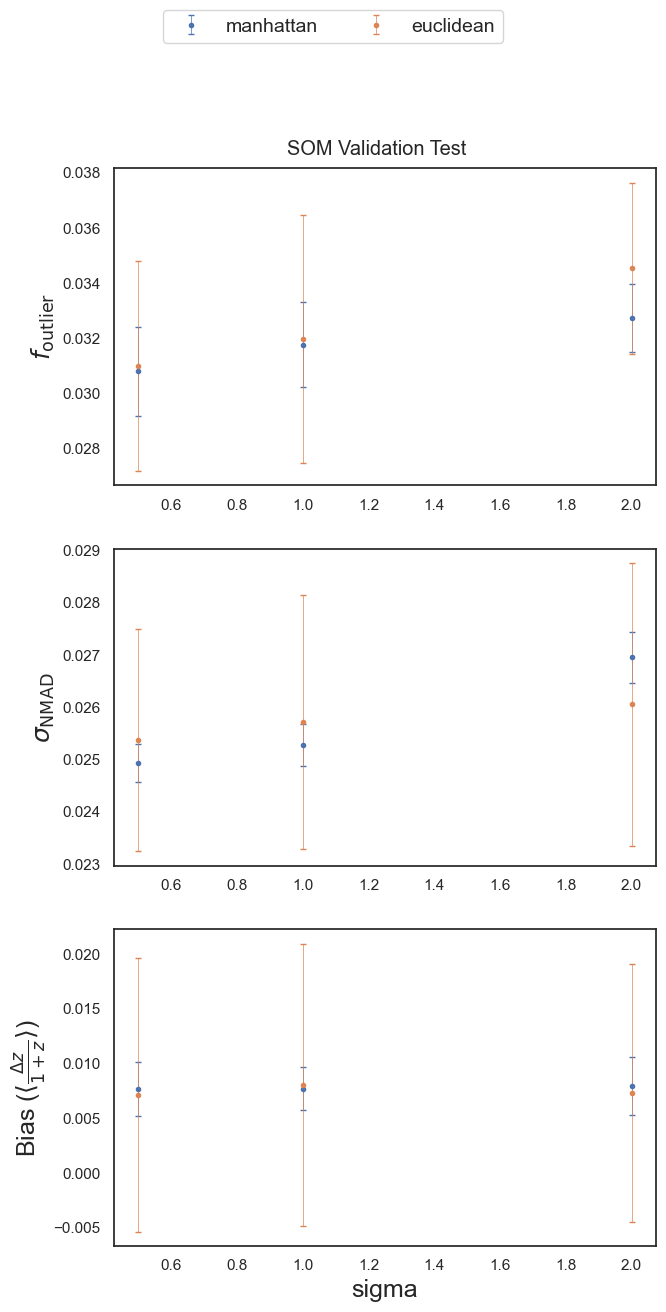

In [26]:
sizes=[(50,100)]
sigmas = [0.5, 1, 2]
learning_rates = [0.8]

filename=None
metrics = ['outliers', 'nmads', 'biases']
labels = r'$f_\mathrm{outlier}$', r'$\sigma_\mathrm{NMAD}$', 'Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')'
fig, axs = plt.subplots(len(metrics), 1, figsize=(7,14))
v1s, v1sl = sizes, 'size'
v2s, v2sl = sigmas, 'sigma'
#cs = 'r', 'g', 'b', '0.5'

for i, metric in enumerate(metrics):
    print(metric)
    for j, dmetric in enumerate(dmetrics):
        vals, errs = [], []
        for k, v2 in enumerate(v2s):
            vals.append(dmetrics_data[dmetric][(sigmas[k], 0.8)][metric+'_mean'])
            errs.append(dmetrics_data[dmetric][(sigmas[k], 0.8)][metric+'_range'])
        print(str(size)+' SOM min. mean:', np.round(np.min(vals), 5), '  (for sigma='+str(v2s[np.argmin(vals)])+')')

        if i==0:
            axs[i].errorbar(v2s, vals, yerr=errs, fmt='o', capsize=2,
                    lw=0.5, ms=3, alpha=1., label=str(dmetric))#, c=cs[j])
        else:
            axs[i].errorbar(v2s, vals, yerr=errs, fmt='o', capsize=2,
                    lw=0.5, ms=3, alpha=1.)#, c=cs[j])
        axs[i].set_ylabel(labels[i], fontsize=18)
    if i==2:
        axs[i].set_xlabel(v2sl, fontsize=18)
    
        
fig.legend(loc='upper center', ncols=3, fontsize=14)
fig.suptitle('SOM Validation Test', y=0.90)

In [52]:
sigs = [1]#, 2, 4]
lrs = [0.8]

params = [(s, lr) for s in sigs for lr in lrs]

In [53]:
sizes=[(12,24),(18,36),(25,50),(35,70),(50,100),(75,150)]
#sizes=[(18, 36),(25, 50), (35,70), (50,100), (75,150)]

In [54]:
sizes_data = {8:data_816, 12:data_1224, 18:data_1836, 25:data_2550, 35:data_3570, 50:data_50100, 75:data_75150}

In [55]:
#sizes=[(46,92), (50,100), (54,108)]
#sizes_data = {46:data_4692, 50:data_50100, 54:data_54108}

#sigs = [0.85, 1, 1.15]
#lrs = [0.68, 0.8, 0.92]


outliers
(12, 24) SOM min. mean: 0.03088   (for sigma=1)
(18, 36) SOM min. mean: 0.02784   (for sigma=1)
(25, 50) SOM min. mean: 0.03102   (for sigma=1)
(35, 70) SOM min. mean: 0.03108   (for sigma=1)
(50, 100) SOM min. mean: 0.03177   (for sigma=1)
(75, 150) SOM min. mean: 0.03025   (for sigma=1)
nmads
(12, 24) SOM min. mean: 0.03051   (for sigma=1)
(18, 36) SOM min. mean: 0.02746   (for sigma=1)
(25, 50) SOM min. mean: 0.02614   (for sigma=1)
(35, 70) SOM min. mean: 0.02606   (for sigma=1)
(50, 100) SOM min. mean: 0.02529   (for sigma=1)
(75, 150) SOM min. mean: 0.02543   (for sigma=1)
biases
(12, 24) SOM min. mean: 0.00786   (for sigma=1)
(18, 36) SOM min. mean: 0.00664   (for sigma=1)
(25, 50) SOM min. mean: 0.00923   (for sigma=1)
(35, 70) SOM min. mean: 0.00819   (for sigma=1)
(50, 100) SOM min. mean: 0.00773   (for sigma=1)
(75, 150) SOM min. mean: 0.00528   (for sigma=1)


Text(0.5, 0.9, 'SOM Validation Test: Manhattan')

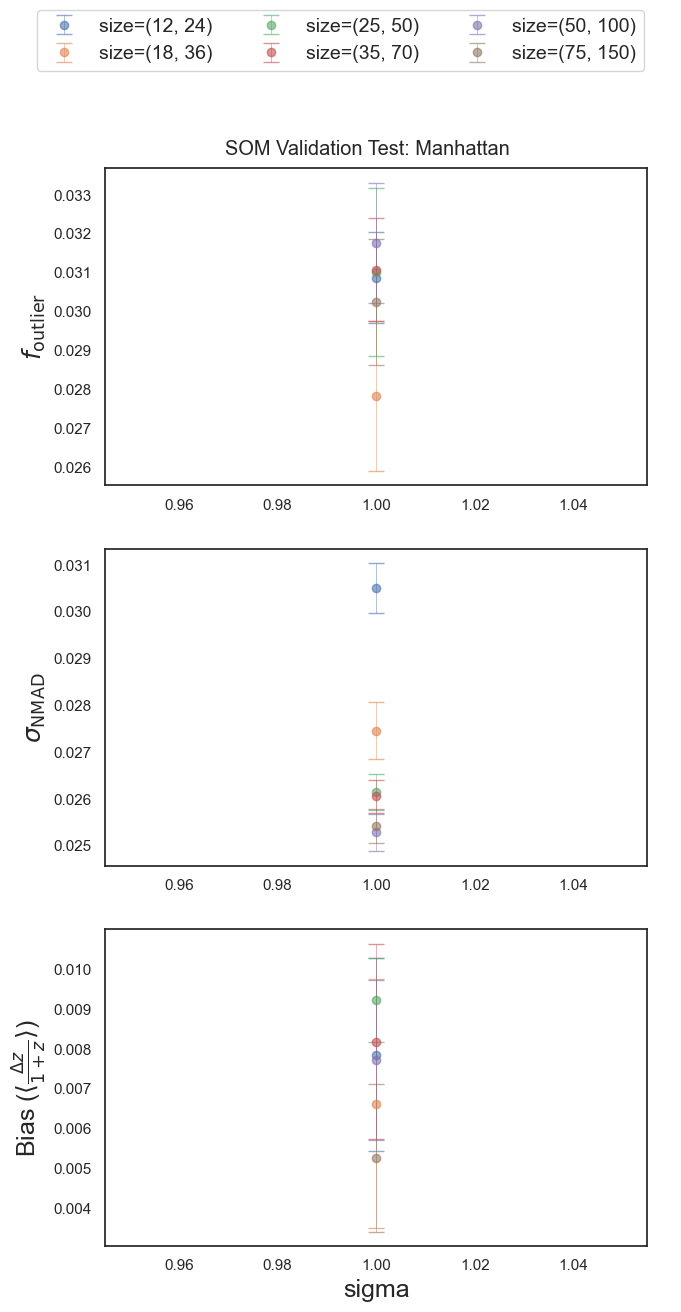

In [57]:
filename=None
metrics = ['outliers', 'nmads', 'biases']
labels = r'$f_\mathrm{outlier}$', r'$\sigma_\mathrm{NMAD}$', 'Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')'
fig, axs = plt.subplots(len(metrics), 1, figsize=(7,14))
v1s, v1sl = sizes, 'size'
v2s, v2sl = sigs, 'sigma'
#cs = 'r', 'g', 'b', '0.5'

for i, metric in enumerate(metrics):
    print(metric)
    for j, size in enumerate(sizes):
        vals, errs = [], []
        for k, v2 in enumerate(v2s):
            vals.append(sizes_data[size[0]][(sigs[k], 0.8)][metric+'_mean'])
            errs.append(sizes_data[size[0]][(sigs[k], 0.8)][metric+'_range'])
        print(str(size)+' SOM min. mean:', np.round(np.min(vals), 5), '  (for sigma='+str(v2s[np.argmin(vals)])+')')

        if i==0:
            axs[i].errorbar(v2s, vals, yerr=errs, fmt='o', capsize=6,
                    lw=0.5, ms=6, alpha=0.6, label=v1sl+'='+str(size))#, c=cs[j])
        else:
            axs[i].errorbar(v2s, vals, yerr=errs, fmt='o', capsize=6,
                    lw=0.5, ms=6, alpha=0.6)#, c=cs[j])
        axs[i].set_ylabel(labels[i], fontsize=18)
    if i==2:
        axs[i].set_xlabel(v2sl, fontsize=18)
    
        
fig.legend(loc='upper center', ncols=3, fontsize=14)
fig.suptitle('SOM Validation Test: Manhattan', y=0.90)

In [57]:
with open("results_highz_260407_8_16.pkl", "rb") as f:
    data_highz_816 = pickle.load(f)

with open("results_highz_260407_12_24.pkl", "rb") as f:
    data_highz_1224 = pickle.load(f)

with open("results_highz_260407_18_36.pkl", "rb") as f:
    data_highz_1836 = pickle.load(f)

with open("results_highz_260407_25_50.pkl", "rb") as f:
    data_highz_2550 = pickle.load(f)

with open("results_highz_260407_35_70.pkl", "rb") as f:
    data_highz_3570 = pickle.load(f)

with open("results_highz_260407_50_100.pkl", "rb") as f:
    data_highz_50100 = pickle.load(f)

with open("results_highz_260407_75_150.pkl", "rb") as f:
    data_highz_75150 = pickle.load(f)

data_highz_75150[(1, 0.8)]

{'counts_mean': 385.4,
 'nn': 75,
 'outliers_mean': 0.014531996500908417,
 'outliers_range': 0.007819123881300046,
 'nmads_mean': 0.03389311297688072,
 'nmads_range': 0.003860261569358793,
 'biases_mean': -0.0005866459428877492,
 'biases_range': 0.0035969072906220315}

In [58]:
sizes_highz_data = {8:data_highz_816, 12:data_highz_1224, 18:data_highz_1836, 25:data_highz_2550, 
                    35:data_highz_3570, 50:data_highz_50100, 75:data_highz_75150}

outliers
(8, 16) SOM min. mean: 0.01765   (for sigma=1)
(12, 24) SOM min. mean: 0.01453   (for sigma=0.25)
(18, 36) SOM min. mean: 0.01194   (for sigma=1)
(25, 50) SOM min. mean: 0.01297   (for sigma=1)
(35, 70) SOM min. mean: 0.00934   (for sigma=1)
(50, 100) SOM min. mean: 0.01453   (for sigma=0.25)
(75, 150) SOM min. mean: 0.01194   (for sigma=0.5)
nmads
(8, 16) SOM min. mean: 0.03896   (for sigma=2)
(12, 24) SOM min. mean: 0.03555   (for sigma=1)
(18, 36) SOM min. mean: 0.03481   (for sigma=0.25)
(25, 50) SOM min. mean: 0.03229   (for sigma=0.5)
(35, 70) SOM min. mean: 0.03265   (for sigma=1)
(50, 100) SOM min. mean: 0.0337   (for sigma=0.25)
(75, 150) SOM min. mean: 0.03332   (for sigma=0.25)
biases
(8, 16) SOM min. mean: -0.00155   (for sigma=0.25)
(12, 24) SOM min. mean: -0.0009   (for sigma=1)
(18, 36) SOM min. mean: -0.00073   (for sigma=0.5)
(25, 50) SOM min. mean: -0.00058   (for sigma=1)
(35, 70) SOM min. mean: -0.00125   (for sigma=0.25)
(50, 100) SOM min. mean: -0.00063  

Text(0.5, 0.9, 'SOM Validation Test: z>1.7')

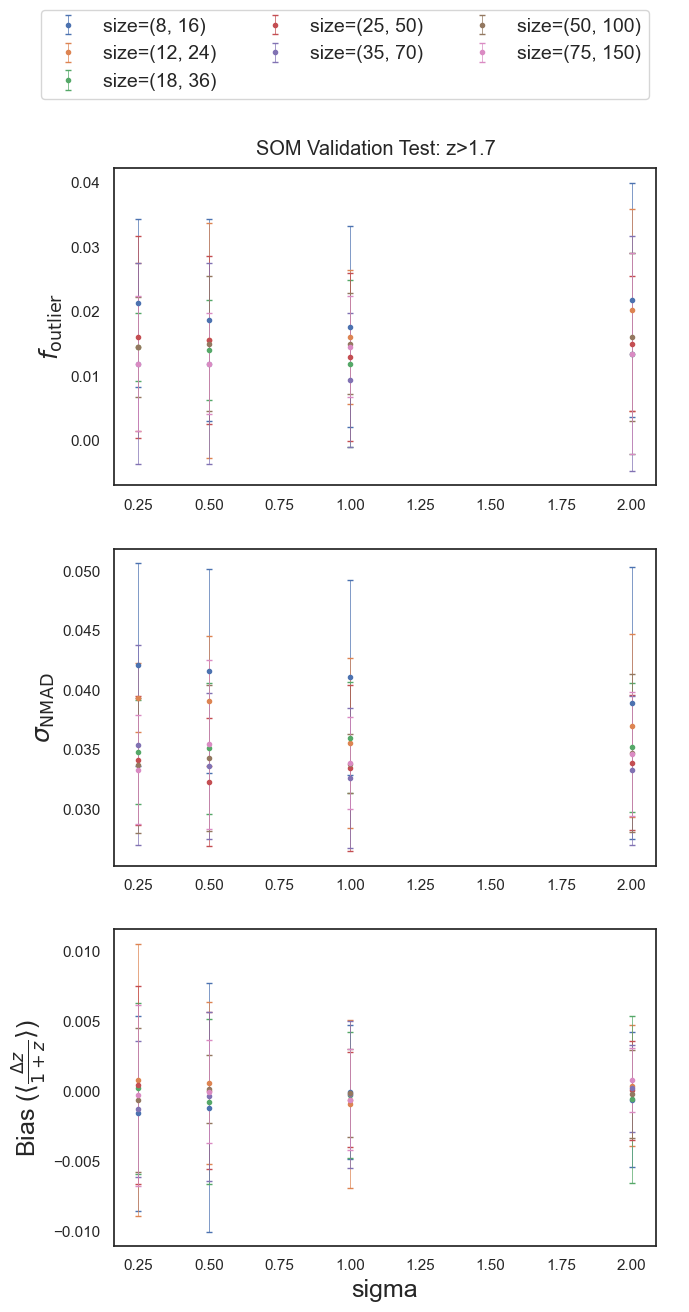

In [60]:
filename=None
metrics = ['outliers', 'nmads', 'biases']
labels = r'$f_\mathrm{outlier}$', r'$\sigma_\mathrm{NMAD}$', 'Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')'
fig, axs = plt.subplots(len(metrics), 1, figsize=(7,14))
v1s, v1sl = sizes, 'size'
v2s, v2sl = sigs, 'sigma'
#cs = 'r', 'g', 'b', '0.5'

for i, metric in enumerate(metrics):
    print(metric)
    for j, size in enumerate(sizes):
        vals, errs = [], []
        for k, v2 in enumerate(v2s):
            vals.append(sizes_highz_data[size[0]][(sigs[k], 0.8)][metric+'_mean'])
            errs.append(sizes_highz_data[size[0]][(sigs[k], 0.8)][metric+'_range'])
        print(str(size)+' SOM min. mean:', np.round(np.min(vals), 5), '  (for sigma='+str(v2s[np.argmin(vals)])+')')

        if i==0:
            axs[i].errorbar(v2s, vals, yerr=errs, fmt='o', capsize=2,
                    lw=0.5, ms=3, alpha=1., label=v1sl+'='+str(size))#, c=cs[j])
        else:
            axs[i].errorbar(v2s, vals, yerr=errs, fmt='o', capsize=2,
                    lw=0.5, ms=3, alpha=1.)#, c=cs[j])
        axs[i].set_ylabel(labels[i], fontsize=18)
    if i==2:
        axs[i].set_xlabel(v2sl, fontsize=18)
    
        
fig.legend(loc='upper center', ncols=3, fontsize=14)
fig.suptitle('SOM Validation Test: z>1.7', y=0.90)

Text(0.5, 0.92, '35x70 SOM Validation Test')

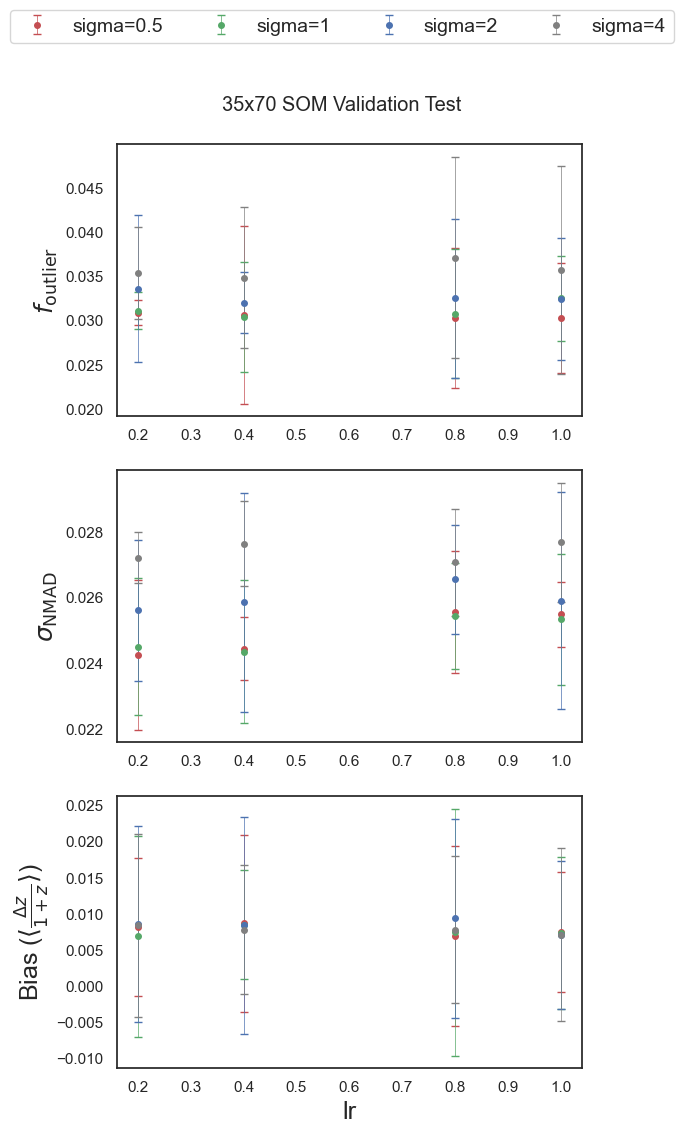

In [24]:
filename=None
metrics = ['outliers', 'nmads', 'biases']
labels = r'$f_\mathrm{outlier}$', r'$\sigma_\mathrm{NMAD}$', 'Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')'
fig, axs = plt.subplots(len(metrics), 1, figsize=(6,12))
v1s, v1sl = sigs, 'sigma'
v2s, v2sl = lrs, 'lr'
cs = 'r', 'g', 'b', '0.5'

for i, metric in enumerate(metrics):
    for j, v1 in enumerate(v1s):
        vals, errs = [], []
        for k, v2 in enumerate(v2s):
            vals.append(data_3570[(sigs[j], lrs[k])][metric+'_mean'])
            errs.append(data_3570[(sigs[j], lrs[k])][metric+'_range'])

        if i==0:
            axs[i].errorbar(v2s, vals, yerr=errs, fmt='o', capsize=3,
                    lw=0.5, ms=4, alpha=1., c=cs[j], label=v1sl+'='+str(v1))
        else:
            axs[i].errorbar(v2s, vals, yerr=errs, fmt='o', capsize=3,
                    lw=0.5, ms=4, alpha=1., c=cs[j])
        axs[i].set_ylabel(labels[i], fontsize=18)
    if i==2:
        axs[i].set_xlabel(v2sl, fontsize=18)
        
fig.legend(loc='upper center', ncols=len(v1s), fontsize=14)
fig.suptitle('35x70 SOM Validation Test', y=0.92)

In [25]:
with open("results_260327_50_100.pkl", "rb") as f:
    data_50100 = pickle.load(f)

data_50100[(0.5, 0.2)]

{'counts_mean': 2895.4,
 'nn': 50,
 'outliers_mean': 0.0305312312140383,
 'outliers_range': 0.003108808290155439,
 'nmads_mean': 0.024183012242276362,
 'nmads_range': 0.0020133047138608633,
 'biases_mean': 0.007636747446618235,
 'biases_range': 0.005199920789663565}

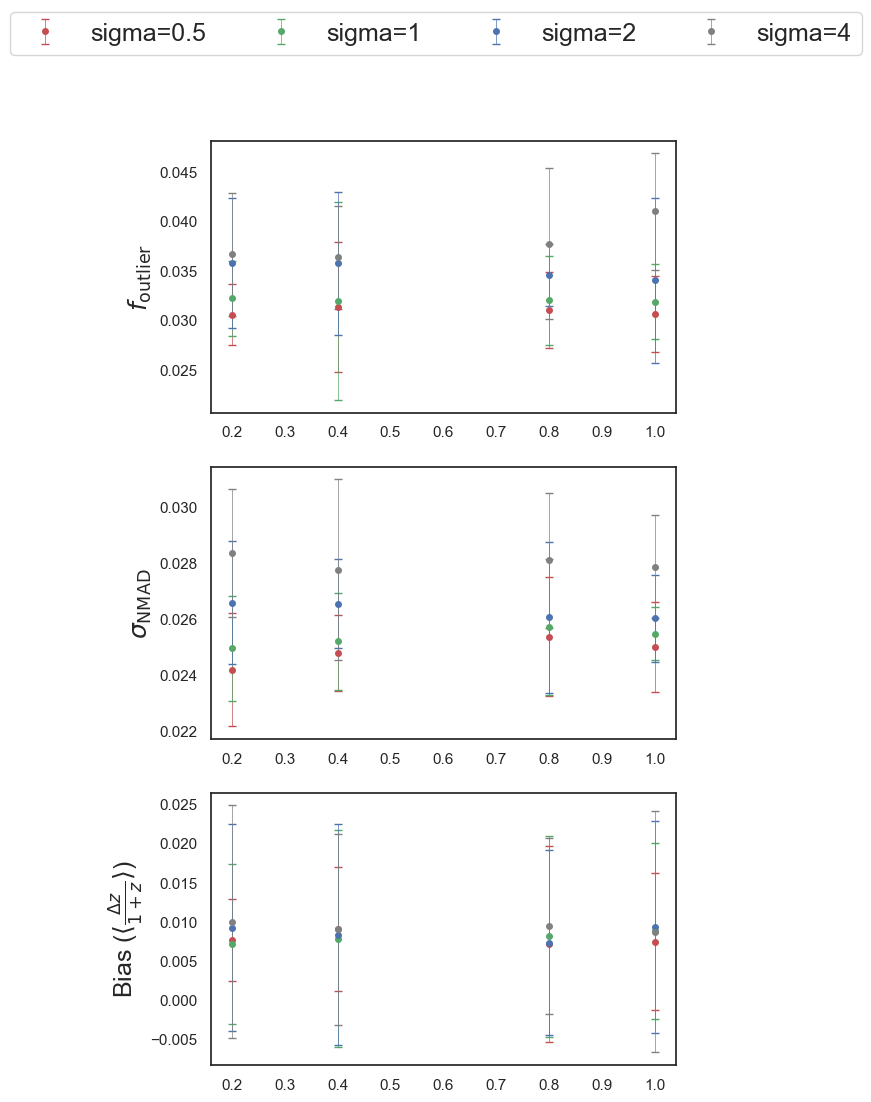

In [26]:
# 50_100
filename=None
metrics = ['outliers', 'nmads', 'biases']
labels = r'$f_\mathrm{outlier}$', r'$\sigma_\mathrm{NMAD}$', 'Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')'
fig, axs = plt.subplots(len(metrics), 1, figsize=(6,12))
v1s, v1sl = sigs, 'sigma'
v2s = lrs
cs = 'r', 'g', 'b', '0.5'

for i, metric in enumerate(metrics):
    for j, v1 in enumerate(v1s):
        vals, errs = [], []
        for v2 in v2s:
            vals.append(data_50100[(v1, v2)][metric+'_mean'])
            errs.append(data_50100[(v1, v2)][metric+'_range'])

        if i==0:
            axs[i].errorbar(v2s, vals, yerr=errs, fmt='o', capsize=3,
                    lw=0.5, ms=4, alpha=1., c=cs[j], label=v1sl+'='+str(v1))
        else:
            axs[i].errorbar(v2s, vals, yerr=errs, fmt='o', capsize=3,
                    lw=0.5, ms=4, alpha=1., c=cs[j])
        axs[i].set_ylabel(labels[i], fontsize=18)
        
fig.legend(loc='upper center', ncols=len(v1s), fontsize=18)
fig.suptitle('50x100 SOM Validation Test', y=0.92)

Text(0.5, 0.92, '50x100 SOM Validation Test')

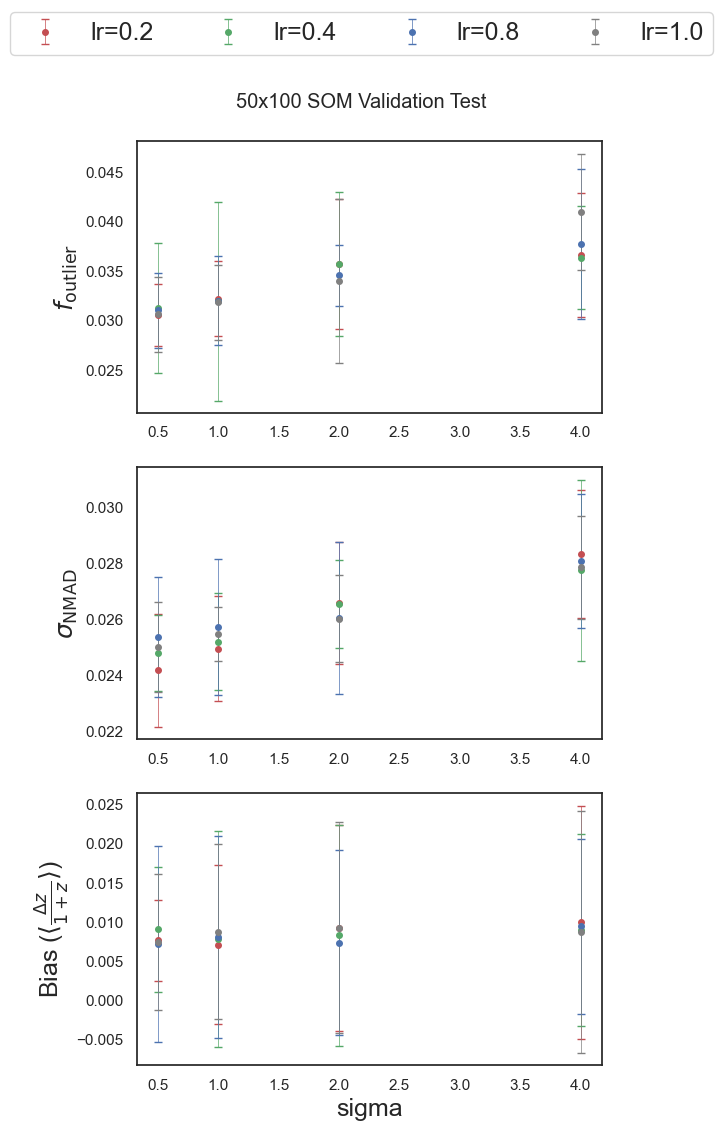

In [27]:
filename=None
metrics = ['outliers', 'nmads', 'biases']
labels = r'$f_\mathrm{outlier}$', r'$\sigma_\mathrm{NMAD}$', 'Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')'
fig, axs = plt.subplots(len(metrics), 1, figsize=(6,12))
v1s, v1sl = lrs, 'lr'
v2s, v2sl = sigs, 'sigma'
cs = 'r', 'g', 'b', '0.5'

for i, metric in enumerate(metrics):
    for j, v1 in enumerate(v1s):
        vals, errs = [], []
        for k, v2 in enumerate(v2s):
            vals.append(data_50100[(sigs[k], lrs[j])][metric+'_mean'])
            errs.append(data_50100[(sigs[k], lrs[j])][metric+'_range'])

        if i==0:
            axs[i].errorbar(v2s, vals, yerr=errs, fmt='o', capsize=3,
                    lw=0.5, ms=4, alpha=1., c=cs[j], label=v1sl+'='+str(v1))
        else:
            axs[i].errorbar(v2s, vals, yerr=errs, fmt='o', capsize=3,
                    lw=0.5, ms=4, alpha=1., c=cs[j])
        axs[i].set_ylabel(labels[i], fontsize=18)
    if i==2:
        axs[i].set_xlabel(v2sl, fontsize=18)
    
        
fig.legend(loc='upper center', ncols=len(v1s), fontsize=18)
fig.suptitle('50x100 SOM Validation Test', y=0.92)

Text(0.5, 0.92, '50x100 SOM Validation Test')

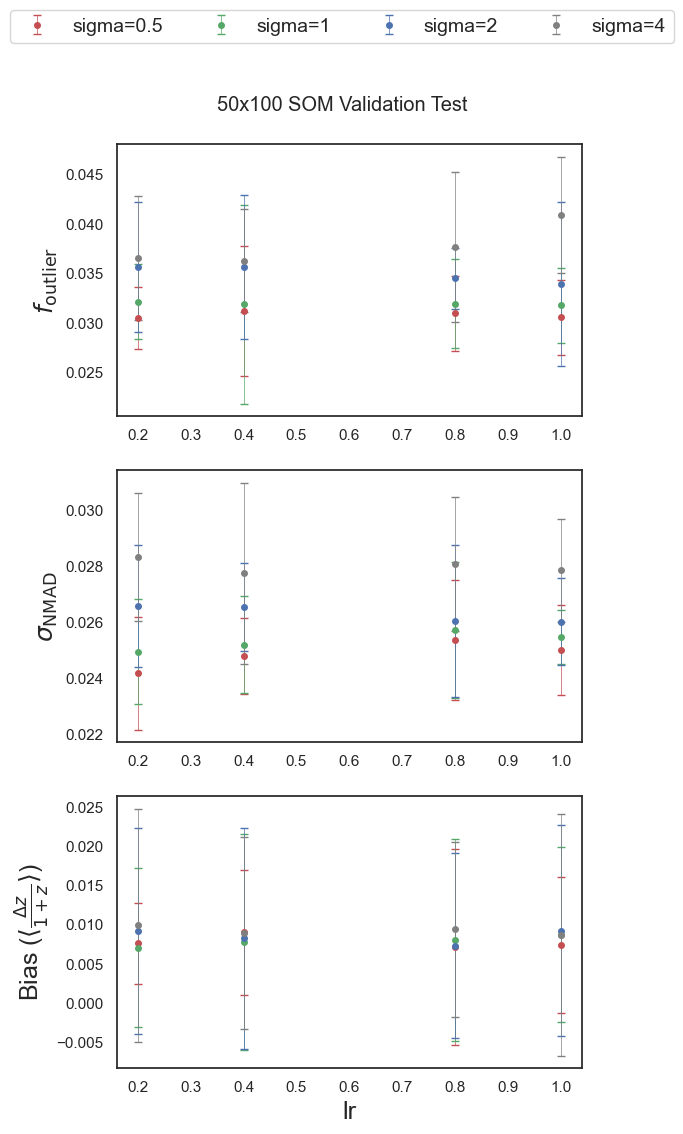

In [28]:
filename=None
metrics = ['outliers', 'nmads', 'biases']
labels = r'$f_\mathrm{outlier}$', r'$\sigma_\mathrm{NMAD}$', 'Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')'
fig, axs = plt.subplots(len(metrics), 1, figsize=(6,12))
v1s, v1sl = sigs, 'sigma'
v2s, v2sl = lrs, 'lr'
cs = 'r', 'g', 'b', '0.5'

for i, metric in enumerate(metrics):
    for j, v1 in enumerate(v1s):
        vals, errs = [], []
        for k, v2 in enumerate(v2s):
            vals.append(data_50100[(sigs[j], lrs[k])][metric+'_mean'])
            errs.append(data_50100[(sigs[j], lrs[k])][metric+'_range'])

        if i==0:
            axs[i].errorbar(v2s, vals, yerr=errs, fmt='o', capsize=3,
                    lw=0.5, ms=4, alpha=1., c=cs[j], label=v1sl+'='+str(v1))
        else:
            axs[i].errorbar(v2s, vals, yerr=errs, fmt='o', capsize=3,
                    lw=0.5, ms=4, alpha=1., c=cs[j])
        axs[i].set_ylabel(labels[i], fontsize=18)
    if i==2:
        axs[i].set_xlabel(v2sl, fontsize=18)
        
fig.legend(loc='upper center', ncols=len(v1s), fontsize=14)
fig.suptitle('50x100 SOM Validation Test', y=0.92)